<a href="https://colab.research.google.com/github/ShritisnigdhaMishra/AML_LAB/blob/main/AML_Assignment_05.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Ridge Regression

Enter the x feature:1,2,3,4
Enter the y feature:2,2,5,4
Weight(w):1.0021
Bias(b):0.5211


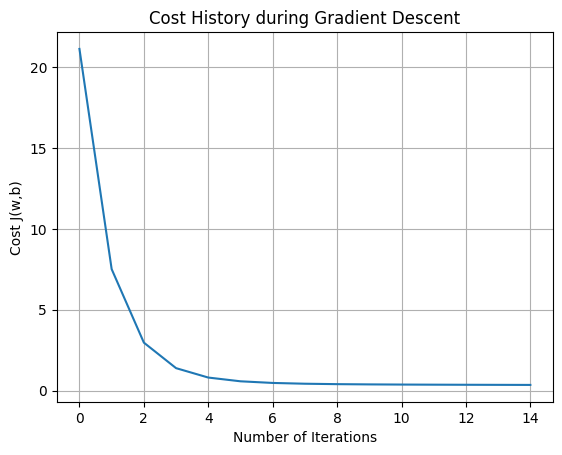

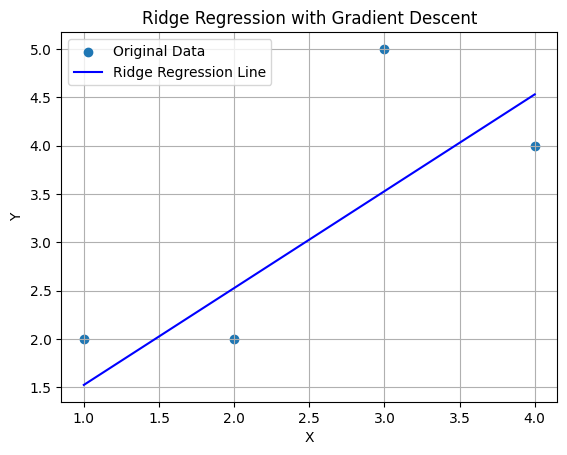

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
def ridge_regression_gd(x,y,learn_rate,n_iter,lam):
  n=len(x)
  w=0.0
  b=0.0
  cost_history=[]
  for i in range(n_iter):
    y_pred=w*x+b
    cost=(1/(2*n)*np.sum(y_pred-y)**2)+(lam/2)*(w**2)
    cost_history.append(cost)
    dJ_dw=(1/n)*np.sum((y_pred-y)*x)+lam*w
    dJ_db=(1/n)*np.sum(y_pred-y)
    w -=learn_rate*dJ_dw
    b -=learn_rate*dJ_db
  return w,b,cost_history
x_input=input("Enter the x feature:")
y_input=input("Enter the y feature:")
x=np.array([float(val) for val in x_input.split(',')])
y=np.array([float(val) for val in y_input.split(',')])
learn_rate=0.05
n_iter=15
lam=0.5
w,b,cost_history=ridge_regression_gd(x,y,learn_rate,n_iter,lam)
print(f"Weight(w):{w:.4f}")
print(f"Bias(b):{b:.4f}")
plt.plot(range(n_iter),cost_history)
plt.xlabel("Number of Iterations")
plt.ylabel("Cost J(w,b)")
plt.title("Cost History during Gradient Descent")
plt.grid(True)
plt.show()
sort_idx=np.argsort(x)
x_sorted=x[sort_idx]
plt.scatter(x,y,label="Original Data")
plt.plot(x_sorted,w*x_sorted+b,color="blue",label="Ridge Regression Line")
plt.xlabel("X")
plt.ylabel("Y")
plt.title("Ridge Regression with Gradient Descent")
plt.legend()
plt.grid(True)
plt.show()

Lasso Regression

Enter x1 values:-1,-1,1,1
Enter x2 values:-1,1,-1,1
Enter y values:-2.2,-1.8,1.8,2.2

Final parameters:w1:1.2026,w2:0.0323,b:0.0000


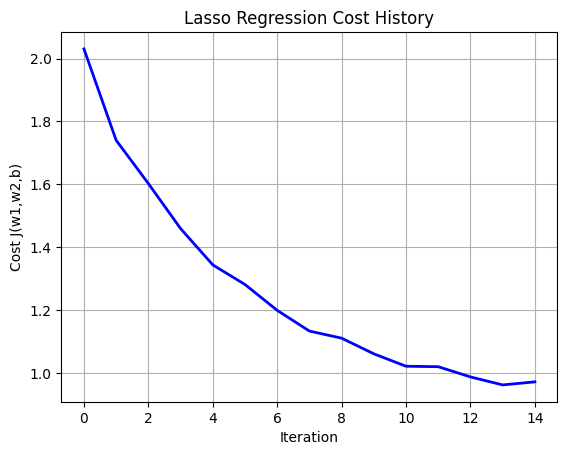

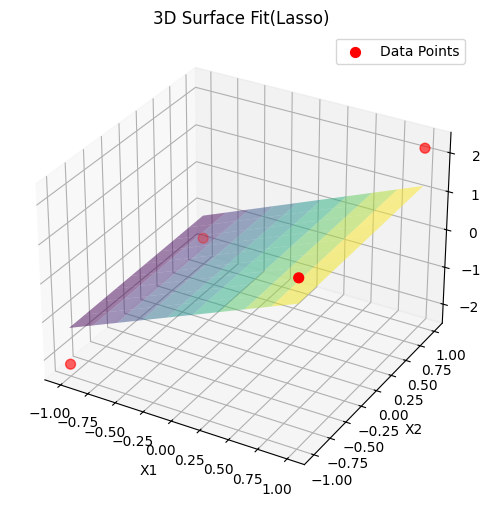

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
def lasso_regression_gd(x1,x2,y,learn_rate,iter,lam):
  n=len(y)
  cost_history=[]
  w1,w2,b=0.0,0.033,0.0
  for i in range(iter):
    y_pred=w1*x1+w2*x2+b
    cost=(1/(2*n))*np.sum((y_pred-y)**2)+lam*(np.abs(w1)+np.abs(w2))
    dw1=(1/n)*np.sum((y_pred-y)*x1)+lam*np.sign(w1)
    dw2=(1/n)*np.sum((y_pred-y)*x2)+lam*np.sign(w2)
    db=(1/n)*np.sum(y_pred-y)
    cost_history.append(cost)
    w1 -=learn_rate*dw1
    w2 -=learn_rate*dw2
    b -=learn_rate*db
  return w1,w2,b,cost_history
x1_input=input("Enter x1 values:")
x2_input=input("Enter x2 values:")
y_input=input("Enter y values:")
x1=np.array([float(v) for v in x1_input.split(',')])
x2=np.array([float(v) for v in x2_input.split(',')])
y=np.array([float(v) for v in y_input.split(',')])
learn_rate=0.1
iter=15
lam=0.5
w1,w2,b,cost_history=lasso_regression_gd(x1,x2,y,learn_rate,iter,lam)
print(f"\nFinal parameters:w1:{w1:.4f},w2:{w2:.4f},b:{b:.4f}")
plt.figure(1)
plt.plot(range(len(cost_history)),cost_history,color="blue",linewidth=2)
plt.xlabel("Iteration")
plt.ylabel("Cost J(w1,w2,b)")
plt.title("Lasso Regression Cost History")
plt.grid(True)
plt.show()
fig=plt.figure(2,figsize=(8,6))
ax=fig.add_subplot(111,projection="3d")
ax.scatter(x1,x2,y,color="red",s=50,label="Data Points")
x1_grid,x2_grid=np.meshgrid(np.linspace(min(x1),max(x1),10),np.linspace(min(x2),max(x2),10))
y_grid=w1*x1_grid+w2*x2_grid+b
ax.plot_surface(x1_grid,x2_grid,y_grid,alpha=0.5,cmap="viridis")
ax.set_xlabel("X1")
ax.set_ylabel("X2")
ax.set_zlabel("Y")
ax.set_title("3D Surface Fit(Lasso)")
plt.legend()
plt.show()